# 05 · Model Comparison — the bake-off

**Phase goal:** fairly compare candidate regressors with cross-validation and understand *why* the tree ensembles win.

| Family | How it learns | Expectation |
| :-- | :-- | :-- |
| **Ridge (linear)** | one weighted sum | underfits — price is non-linear |
| **Decision Tree** | one greedy flowchart | overfits, high variance |
| **Random Forest** | *bagging* — average of many trees | strong, low-tuning |
| **HistGradientBoosting** | *boosting* — trees fix prior errors | strong, fast |
| **XGBoost / LightGBM** | regularised boosting | usually best on tabular |

In [1]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')
import json, pandas as pd, matplotlib.pyplot as plt
from car_pricing import config
# Load the committed comparison (re-run `python -m car_pricing.train` to refresh).
comp = json.loads(config.COMPARISON_PATH.read_text())
tbl = pd.DataFrame(comp).T.sort_values('cv_mae')
tbl[['cv_mae','cv_std','cv_time_s']].round(3)

,cv_mae,cv_std,cv_time_s
XGBoost,0.708,0.007,1.511
LightGBM,0.715,0.004,3.003
HistGradientBoosting,0.732,0.006,2.125
Random Forest,0.745,0.004,2.763
Decision Tree,0.860,0.005,0.195
Ridge (linear),1.184,0.027,0.122


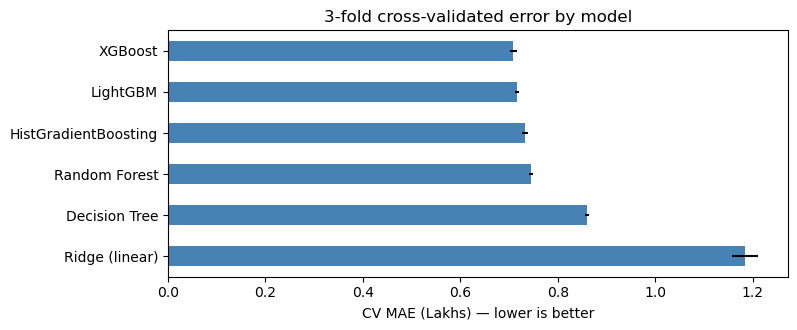

In [2]:
ax = tbl['cv_mae'].plot.barh(xerr=tbl['cv_std'], figsize=(8,3.2), color='steelblue')
ax.set_xlabel('CV MAE (Lakhs) — lower is better')
ax.set_title('3-fold cross-validated error by model'); ax.invert_yaxis(); plt.show()

### DT vs RF vs XGBoost vs LightGBM — what the numbers show
- **Linear** is far behind: price depends on non-linear interactions (brand × age × engine) a single weighted sum can't capture.
- A **single tree** improves a lot but is the weakest ensemble baseline.
- **Random Forest** (bagging) and the **boosters** cluster at the top; the gradient boosters (**HistGB / XGBoost / LightGBM**) edge out RF with fewer, shallower trees — *and* far smaller models.
- **XGBoost vs LightGBM** is a near-tie here (well within one std). Which one *ships* is decided in nb 06 — and it's not purely about MAE.

See [`docs/MODEL_CARD.md`](../docs/MODEL_CARD.md).